In [25]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.optim as optim

In [26]:
data_train = datasets.MNIST(root='data/', train=True, download=True, transform=transforms.ToTensor())
data_test = datasets.MNIST(root='data/', train=False, download=True, transform=transforms.ToTensor())

In [27]:
train = DataLoader(data_train, batch_size=32)
test = DataLoader(data_test, batch_size=32)

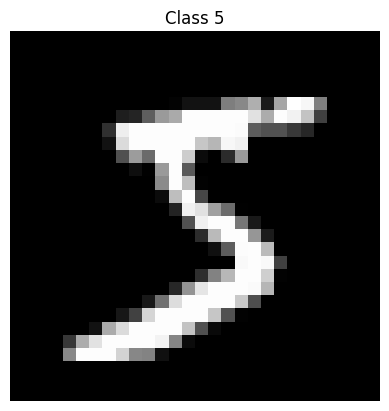

In [28]:
image, lable = next(iter(train))
plt.imshow(image[0].squeeze(), cmap='gray')
plt.title(f'Class {lable[0]}')
plt.axis('off')
plt.show()

In [29]:
class CheckImage(nn.Module):
  def __init__(self):
    super().__init__()

    self.first = nn.Sequential(
        nn.Conv2d(1, 16, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.second = nn.Sequential(
        nn.Flatten(),
        nn.Linear(16 * 14 * 14, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )
  def forward(self, x):
    x = self.first(x)
    x = self.second(x)
    return x

In [30]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [31]:
model = CheckImage().to(device)

In [32]:
loss_fn  = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [33]:
for epoch in range(10):
  model.train()
  total_loss = 0
  for x_batch, y_batch in train:
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)

    y_pred = model(x_batch)
    loss = loss_fn(y_pred, y_batch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_loss += loss.item()

  print(f'Epoch: {epoch+1}, Loss: {total_loss/len(train)}')



Epoch: 1, Loss: 0.26976339388738074
Epoch: 2, Loss: 0.08840366947585716
Epoch: 3, Loss: 0.0629819361366642
Epoch: 4, Loss: 0.04881885564403298
Epoch: 5, Loss: 0.038738471530432195
Epoch: 6, Loss: 0.03040710344357358
Epoch: 7, Loss: 0.023724616766041436
Epoch: 8, Loss: 0.019007323162669492
Epoch: 9, Loss: 0.015067918799382459
Epoch: 10, Loss: 0.012043692752751547


In [34]:
model_eval = model.eval()

In [35]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
  for x_batch, y_batch in test:
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
    y_pred = model(x_batch)
    pred = torch.max(y_pred, dim=1)
    total += y_batch.size(0)
    correct += (pred.indices == y_batch).sum().item()
accuracy = 100 * correct/total
print(f'Accuracy: {accuracy} %')

Accuracy: 98.16 %


In [36]:
torch.save(model.state_dict(), 'model.pth')